# Phân tích chẩn đoán

## 1. Chuẩn bị dữ liệu

### 1.1. Load dữ liệu

In [1]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [286]:
customers = pd.read_csv("../data/2_clean/customers.csv")
orders = pd.read_csv("../data/2_clean/orders.csv")
order_items = pd.read_csv("../data/2_clean/order_items.csv")
payments = pd.read_csv("../data/2_clean/payments.csv")
products = pd.read_csv("../data/2_clean/products.csv")
reviews = pd.read_csv("../data/2_clean/reviews.csv")
geolocation = pd.read_csv("../data/2_clean/geolocation.csv")
sellers = pd.read_csv("../data/2_clean/sellers.csv")

### 1.2. Phân loại cảm xúc
**Mục tiêu:** phân loại các đánh giá dưới 3 sao theo `negative / positive / neutral`

In [3]:
reviews

,review_id,order_id,review_score,review_comment_message
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...
...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,"Excelente mochila, entrega super rápida. Super..."
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN


In [4]:
df = reviews[(~reviews["review_comment_message"].isnull()) & (reviews["review_score"] < 3)]
display(df[["review_id", "review_comment_message"]])

,review_id,review_comment_message
16,9314d6f9799f5bfba510cc7bcd468c01,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,373cbeecea8286a2b66c97b1b157ec46,Péssimo
29,2c5e27fc178bde7ac173c9c62c31b070,Não gostei ! Comprei gato por lebre
32,58044bca115705a48fe0e00a21390c54,Sempre compro pela Internet e a entrega ocorre...
39,9fd59cd04b42f600df9f25e54082a8d1,Nada de chegar o meu pedido.
...,...,...
99155,2fc8295a24978092328d3a329d22940e,Eu recebi o seguinte email e preciso saber com...
99169,3450ec3bbabeb09a08b00fc72da87a30,Boa tarde. \r\nNão recebo todos os produtos fa...
99200,2ee221b28e5b6fceffac59487ed39348,Foto muito diferente principalmente a graninha...
99203,5085bc489aa6b58a29c4f922d59ff826,Tive um problema na entrega em que o correio c...


In [5]:
#!pip install pysentimiento   

In [6]:
#!pip install --upgrade accelerate

In [7]:
#!pip install --upgrade torch transformers

In [8]:
import accelerate
import torch
import transformers

print(accelerate.__version__)    # >=0.26.0
print(torch.__version__)         # >=2.0
print(transformers.__version__)  # >=4.13

c:\Users\sonvuuu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.12.0
2.9.1+cpu
4.57.3


In [7]:
import pandas as pd
from pysentimiento import create_analyzer

# Tạo analyzer sentiment cho tiếng Bồ Đào Nha
analyzer = create_analyzer(task="sentiment", lang="pt")

# Hàm map label sang Positive / Neutral / Negative
def map_label(label):
    return {
        "NEG": "Negative",
        "NEU": "Neutral",
        "POS": "Positive"
    }.get(label, "Neutral")

# Batch size
batch_size = 32
sentiments = []

# Chia comment thành batch
comments = df['review_comment_message'].tolist()
for i in range(0, len(comments), batch_size):
    batch = comments[i:i+batch_size]
    results = analyzer.predict(batch)  # pysentimiento hỗ trợ batch
    sentiments.extend([map_label(r.output) for r in results])

# Gán kết quả vào DataFrame
df['sentiment'] = sentiments

# Hiển thị 5 dòng đầu
print(df.head())

c:\Users\sonvuuu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 32/32 [00:00<00:00, 2279.24 examples/s]
c:\Users\sonvuuu\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Map: 100%|██████████| 10/10 [00:00<00:00, 1514.30 examples/s]


                           review_id                          order_id  \
16  9314d6f9799f5bfba510cc7bcd468c01  0dacf04c5ad59fd5a0cc1faa07c34e39   
19  373cbeecea8286a2b66c97b1b157ec46  583174fbe37d3d5f0d6661be3aad1786   
29  2c5e27fc178bde7ac173c9c62c31b070  0ce9a24111d850192a933fcaab6fbad3   
32  58044bca115705a48fe0e00a21390c54  68e55ca79d04a79f20d4bfc0146f4b66   
39  9fd59cd04b42f600df9f25e54082a8d1  3c314f50bc654f3c4e317b055681dff9   

    review_score                             review_comment_message sentiment  
16             2  GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...  Negative  
19             1                                            Péssimo  Negative  
29             1                Não gostei ! Comprei gato por lebre  Negative  
32             1  Sempre compro pela Internet e a entrega ocorre...  Negative  
39             1                       Nada de chegar o meu pedido.  Negative  


C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_10028\2771575334.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = sentiments


In [8]:
df

,review_id,order_id,review_score,review_comment_message,sentiment
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",Negative
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Péssimo,Negative
29,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,Não gostei ! Comprei gato por lebre,Negative
32,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,Sempre compro pela Internet e a entrega ocorre...,Negative
39,9fd59cd04b42f600df9f25e54082a8d1,3c314f50bc654f3c4e317b055681dff9,1,Nada de chegar o meu pedido.,Negative
...,...,...,...,...,...
99155,2fc8295a24978092328d3a329d22940e,e809c167a9cfd31aee1293abe8995065,1,Eu recebi o seguinte email e preciso saber com...,Neutral
99169,3450ec3bbabeb09a08b00fc72da87a30,c46f950813dd2dd9bab4188dceb83175,1,Boa tarde. \r\nNão recebo todos os produtos fa...,Neutral
99200,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto muito diferente principalmente a graninha...,Neutral
99203,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,Tive um problema na entrega em que o correio c...,Negative


In [9]:
import os

# Lưu từng DataFrame
output_dir = "../data/3_sentiment"

df.to_csv(os.path.join(output_dir, "reviews_1.csv"), index=False)

In [43]:
df = pd.read_csv("../data/3_sentiment/reviews_1.csv")
df = df[df["sentiment"] == "Positive"]
df

,review_id,order_id,review_score,review_comment_message,sentiment
80,7b66de927426b71a817aa36df5e8a0b3,634e8f4c0f6744a626f77f39770ac6aa,1,Muito bom o produto e preço cobrado!,Positive
85,8bc4d875dbab927e9190060688edc80f,b6e5ddeaf2e5b56015e295beb333f305,2,Excelente produto indico a qualquer pessoa.,Positive
126,b42955e5003fa4e9449770fb8b50d30d,1f186ad4ad389666cd9482ce1942038d,2,Demorou mas entregou!,Positive
258,d04bfe3b90e5436b03b65e86d8b6e62d,9292f2ff747a4f8c6580fc8377bb1c8b,2,Apesar da demora na entrega. No mais foi tudo ...,Positive
314,488f5ad66f112743c91ae61731522375,5e3ec924bc1a1f3793e12632c2b2f85d,1,muito obrigado\r\n,Positive
...,...,...,...,...,...
10532,14876c10d791683465f83751ff33064d,296752c5e35a99dd06b9100ab400c8eb,2,Produto bom,Positive
10540,0ba0eb2b255cfe3925088677a49add35,cf5439c6b13deafe107ecca7dcc58b80,1,"paguei 80 rreais de frete, quero esse produro ...",Positive
10626,c0881b2797529c9af9325018e7fbb694,fd7eb2117233aa5ac29e94a28e082077,1,o produto era exatamente o que eu precisasa,Positive
10636,9740c39fe70be3fdd5b610c34358a278,be73d4698f2f4939662dd7788cf3dad3,2,Até as que dão no lava car e postos de gasolin...,Positive


### 1.3. Phân loại thể loại
**Mục tiêu:** phân loại các đánh giá dưới 3 sao theo `negative / positive / neutral`

In [86]:
import pandas as pd

df = pd.read_csv("../data/3_sentiment/reviews_1.csv")
df = df[df["sentiment"] != "Positive"]

In [87]:
import requests
import time

# ================== CONFIG ==================

URL = "http://172.30.224.1:1234/v1/responses"
MODEL = "llama-3-groq-8b-tool-use:2"

system_prompt = """
You are a strict classification engine.

Your task:
- Classify e-commerce user comments written in Brazilian Portuguese.
- Classify each comment into EXACTLY ONE category.
- Focus ONLY on the main complaint or feedback.
- Choose the MOST DOMINANT issue if multiple are mentioned.
- Ignore greetings, politeness, emojis, or irrelevant details.

Categories:
Logistics
Seller
Platform
Customer Service
Other

Rules:
- Output EXACTLY one category name
- Do NOT translate the comment
- Do NOT explain
- Do NOT add punctuation
- Do NOT add numbering
- Do NOT output multiple labels
- You MUST choose one label from the Categories list. Never invent new labels.

Priority rules:
- If lack of response, refund handling, dispute resolution, or support after purchase is mentioned,
  this is the dominant issue.

Classification rules:
- If the dominant issue is lack of response or post-purchase support, choose Customer Service.
- If the dominant issue is platform processes (refund system, payment system, app or website issues),
  choose Platform.
- If the customer has not received the product and the dominant issue is delivery delay or non-delivery,
  choose Logistics.
- If the issue is related to product quality, wrong item, seller behavior, or packaging,
  choose Seller.
- Otherwise, choose Other.
"""

ALLOWED_LABELS = [
    "Logistics",
    "Seller",
    "Platform",
    "Customer Service",
    "Other"
]

# ================== CLASSIFY FUNCTION ==================

def classify_comment(text: str) -> str:
    payload = {
        "model": MODEL,
        "temperature": 0,
        "top_p": 1,
        "input": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ]
    }

    try:
        res = requests.post(URL, json=payload, timeout=30)
        res.raise_for_status()
        label = res.json()["output"][0]["content"][0]["text"].strip()

        # Safety clamp
        if label not in ALLOWED_LABELS:
            return "Other"

        return label

    except Exception as e:
        print("Error:", e)
        return "Other"


df["category"] = df["review_comment_message"].apply(classify_comment)

In [88]:
df

,review_id,order_id,review_score,review_comment_message,sentiment,category
0,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",Negative,Seller
1,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Péssimo,Negative,Other
2,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,Não gostei ! Comprei gato por lebre,Negative,Seller
3,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,Sempre compro pela Internet e a entrega ocorre...,Negative,Logistics
4,9fd59cd04b42f600df9f25e54082a8d1,3c314f50bc654f3c4e317b055681dff9,1,Nada de chegar o meu pedido.,Negative,Logistics
...,...,...,...,...,...,...
10885,2fc8295a24978092328d3a329d22940e,e809c167a9cfd31aee1293abe8995065,1,Eu recebi o seguinte email e preciso saber com...,Neutral,Customer Service
10886,3450ec3bbabeb09a08b00fc72da87a30,c46f950813dd2dd9bab4188dceb83175,1,Boa tarde. \r\nNão recebo todos os produtos fa...,Neutral,Customer Service
10887,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto muito diferente principalmente a graninha...,Neutral,Seller
10888,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,Tive um problema na entrega em que o correio c...,Negative,Customer Service


In [89]:
import os

# Lưu từng DataFrame
output_dir = "../data/3_sentiment"

df.to_csv(os.path.join(output_dir, "reviews_2.csv"), index=False)

In [111]:
import pandas as pd

df = pd.read_csv("../data/3_sentiment/reviews_1.csv")
df = df[df["sentiment"] == "Positive"]

In [125]:
import requests
import time

# ================== CONFIG ==================

URL = "http://172.30.224.1:1234/v1/responses"
MODEL = "llama-3-groq-8b-tool-use:2"

system_prompt = """
You are a strict classification engine.

Your task:
- Read e-commerce reviews written in Brazilian Portuguese
- Identify WHAT the customer praises, if any
- Focus ONLY on positive statements
- Ignore complaints, ratings, or negative parts

Categories:
Product
Delivery
Seller
CustomerService
Platform
PraiseOnly

Rules:
- Output EXACTLY one category name
- Do NOT translate the comment
- Do NOT explain
- Do NOT add punctuation
- Do NOT output multiple labels

Category definitions:
- Product: praises product quality, usefulness, or performance
- Delivery: praises delivery speed, care, or packaging
- Seller: praises seller attitude or communication
- CustomerService: praises support or problem handling
- Platform: praises app or website experience
- PraiseOnly: comment only contains praise, no complaints or negative statements (full praise, possibly misrated)

Important:
- If comment contains only praise, output PraiseOnly
- If comment contains both praise and complaints, output the category of the MOST DOMINANT praised aspect
"""


ALLOWED_LABELS = [
    "Product",
    "Delivery",
    "Seller",
    "CustomerService",
    "Platform",
    "PraiseOnly"
]

# ================== CLASSIFY FUNCTION ==================

def classify_comment(text: str) -> str:
    payload = {
        "model": MODEL,
        "temperature": 0,
        "top_p": 1,
        "input": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ]
    }

    try:
        res = requests.post(URL, json=payload, timeout=30)
        res.raise_for_status()
        label = res.json()["output"][0]["content"][0]["text"].strip()

        # Safety clamp
        if label not in ALLOWED_LABELS:
            return "Other"

        return label

    except Exception as e:
        print("Error:", e)
        return "Other"


df["category"] = df["review_comment_message"].apply(classify_comment)

In [126]:
df["category"].value_counts()

category
Product            158
Delivery            23
Seller              11
CustomerService      9
Other                9
PraiseOnly           3
Platform             1
Name: count, dtype: int64

In [127]:
df

,review_id,order_id,review_score,review_comment_message,sentiment,category
80,7b66de927426b71a817aa36df5e8a0b3,634e8f4c0f6744a626f77f39770ac6aa,1,Muito bom o produto e preço cobrado!,Positive,Product
85,8bc4d875dbab927e9190060688edc80f,b6e5ddeaf2e5b56015e295beb333f305,2,Excelente produto indico a qualquer pessoa.,Positive,Product
126,b42955e5003fa4e9449770fb8b50d30d,1f186ad4ad389666cd9482ce1942038d,2,Demorou mas entregou!,Positive,Delivery
258,d04bfe3b90e5436b03b65e86d8b6e62d,9292f2ff747a4f8c6580fc8377bb1c8b,2,Apesar da demora na entrega. No mais foi tudo ...,Positive,Delivery
314,488f5ad66f112743c91ae61731522375,5e3ec924bc1a1f3793e12632c2b2f85d,1,muito obrigado\r\n,Positive,Product
...,...,...,...,...,...,...
10532,14876c10d791683465f83751ff33064d,296752c5e35a99dd06b9100ab400c8eb,2,Produto bom,Positive,Product
10540,0ba0eb2b255cfe3925088677a49add35,cf5439c6b13deafe107ecca7dcc58b80,1,"paguei 80 rreais de frete, quero esse produro ...",Positive,Product
10626,c0881b2797529c9af9325018e7fbb694,fd7eb2117233aa5ac29e94a28e082077,1,o produto era exatamente o que eu precisasa,Positive,Product
10636,9740c39fe70be3fdd5b610c34358a278,be73d4698f2f4939662dd7788cf3dad3,2,Até as que dão no lava car e postos de gasolin...,Positive,Product


In [128]:
import os

# Lưu từng DataFrame
output_dir = "../data/3_sentiment"

df.to_csv(os.path.join(output_dir, "reviews_3.csv"), index=False)

## 2. Phân tích chẩn đoán

### 1. Chẩn đoán "Nội dung đánh giá"
**Mục tiêu**: Giải mã lý do thực sự đằng sau các con số 1 sao, 2 sao. Dữ liệu số (Rating) chỉ cho biết mức độ, dữ liệu chữ (Comment) mới cho biết nguyên nhân.
- Có trường hợp nào khách đánh giá 1-2 sao nhưng comment tích cực không? Tại sao?
- Trong tổng số các đánh giá tiêu cực (1-2 sao), tỷ lệ phần trăm dành cho các vấn đề liên quan đến Vận Chuyển (Logistics) và các vấn đề do Người Bán (Seller) gây ra (thường liên quan đến sản phẩm) là bao nhiêu?

#### Có trường hợp nào khách đánh giá 1-2 sao nhưng comment tích cực không? Tại sao?

In [153]:
df = pd.read_csv("../data/3_sentiment/reviews_3.csv")

In [154]:
df

,review_id,order_id,review_score,review_comment_message,sentiment,category
0,7b66de927426b71a817aa36df5e8a0b3,634e8f4c0f6744a626f77f39770ac6aa,1,Muito bom o produto e preço cobrado!,Positive,Product
1,8bc4d875dbab927e9190060688edc80f,b6e5ddeaf2e5b56015e295beb333f305,2,Excelente produto indico a qualquer pessoa.,Positive,Product
2,b42955e5003fa4e9449770fb8b50d30d,1f186ad4ad389666cd9482ce1942038d,2,Demorou mas entregou!,Positive,Delivery
3,d04bfe3b90e5436b03b65e86d8b6e62d,9292f2ff747a4f8c6580fc8377bb1c8b,2,Apesar da demora na entrega. No mais foi tudo ...,Positive,Delivery
4,488f5ad66f112743c91ae61731522375,5e3ec924bc1a1f3793e12632c2b2f85d,1,muito obrigado\r\n,Positive,Product
...,...,...,...,...,...,...
209,14876c10d791683465f83751ff33064d,296752c5e35a99dd06b9100ab400c8eb,2,Produto bom,Positive,Product
210,0ba0eb2b255cfe3925088677a49add35,cf5439c6b13deafe107ecca7dcc58b80,1,"paguei 80 rreais de frete, quero esse produro ...",Positive,Product
211,c0881b2797529c9af9325018e7fbb694,fd7eb2117233aa5ac29e94a28e082077,1,o produto era exatamente o que eu precisasa,Positive,Product
212,9740c39fe70be3fdd5b610c34358a278,be73d4698f2f4939662dd7788cf3dad3,2,Até as que dão no lava car e postos de gasolin...,Positive,Product


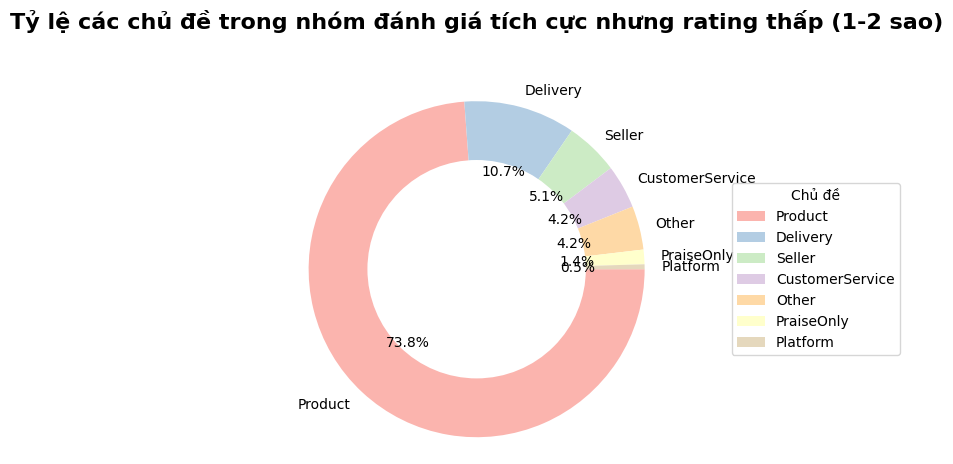

In [156]:
# Chuẩn bị dữ liệu
df1 = df['category'].value_counts().reset_index()
df1.columns = ['category', 'count']

# Tạo màu sắc đẹp mắt (palette pastel)
colors = plt.cm.Pastel1(range(len(df1)))

# Vẽ biểu đồ donut
plt.pie(
    df1['count'],
    labels=df1['category'],
    autopct='%1.1f%%',
    counterclock=False,   # xoay theo chiều kim đồng hồ
    colors=colors,
)

# Thêm vòng tròn trắng ở giữa để tạo donut
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

# Căn chỉnh
plt.axis('equal')  # giữ hình tròn cân đối
plt.title(
    "Tỷ lệ các chủ đề trong nhóm đánh giá tích cực nhưng rating thấp (1-2 sao)",
    fontsize=16,
    fontweight='bold',
    pad=40
)

# Thêm chú thích (legend) bên cạnh
plt.legend(
    df1['category'],
    title="Chủ đề",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.show()

**Nhận xét**
- Sản phẩm vẫn được đánh giá cao 73.8% lời khen trong các review 1-2 sao tập trung vào Product, chứng tỏ chất lượng sản phẩm được khách hàng công nhận.

- Lỗi nghiêm trọng lấn át lời khen: Mặc dù khách khen Sản phẩm, Giao hàng hay Dịch vụ, các lỗi về vận hành, Seller hay CS khiến sao thấp.

- Ưu tiên cải thiện lỗi: Khắc phục triệt để các vấn đề ngoài sản phẩm sẽ giúp chuyển các review 1-2 sao có khen thành 4-5 sao thực sự.

- Hành động ưu tiên: Cần lọc các comment 1-2 sao có nội dung hoàn toàn tích cực để liên hệ, xác nhận lỗi gõ nhầm sao và đề nghị khách hàng chỉnh sửa.

#### Trong tổng số các đánh giá tiêu cực (1-2 sao), tỷ lệ phần trăm dành cho các vấn đề liên quan đến Vận Chuyển (Logistics) và các vấn đề do Người Bán (Seller) gây ra (thường liên quan đến sản phẩm) là bao nhiêu?

In [157]:
df = pd.read_csv("../data/3_sentiment/reviews_2.csv")

In [158]:
df

,review_id,order_id,review_score,review_comment_message,sentiment,category
0,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",Negative,Seller
1,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Péssimo,Negative,Other
2,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,Não gostei ! Comprei gato por lebre,Negative,Seller
3,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,Sempre compro pela Internet e a entrega ocorre...,Negative,Logistics
4,9fd59cd04b42f600df9f25e54082a8d1,3c314f50bc654f3c4e317b055681dff9,1,Nada de chegar o meu pedido.,Negative,Logistics
...,...,...,...,...,...,...
10671,2fc8295a24978092328d3a329d22940e,e809c167a9cfd31aee1293abe8995065,1,Eu recebi o seguinte email e preciso saber com...,Neutral,Customer Service
10672,3450ec3bbabeb09a08b00fc72da87a30,c46f950813dd2dd9bab4188dceb83175,1,Boa tarde. \r\nNão recebo todos os produtos fa...,Neutral,Customer Service
10673,2ee221b28e5b6fceffac59487ed39348,f2d12dd37eaef72ed7b1186b2edefbcd,2,Foto muito diferente principalmente a graninha...,Neutral,Seller
10674,5085bc489aa6b58a29c4f922d59ff826,18ed848509774f56cc8c1c0a1903ad7f,2,Tive um problema na entrega em que o correio c...,Negative,Customer Service


In [159]:
df[["category"]].value_counts()

category        
Seller              5913
Logistics           2488
Customer Service    1867
Platform             253
Other                155
Name: count, dtype: int64

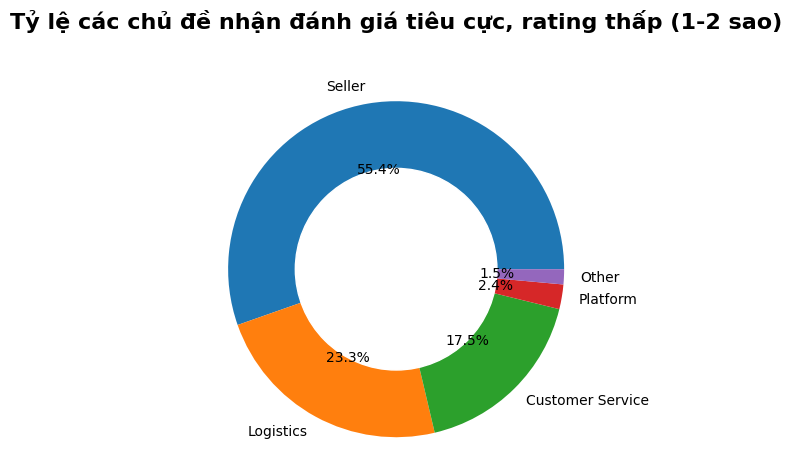

In [161]:
df1 = df['category'].value_counts().reset_index()
df1.columns = ['category', 'count']

plt.pie(df1['count'], labels=df1['category'], autopct='%1.1f%%')
plt.gca().add_artist(plt.Circle((0, 0), 0.6, color='white'))
plt.axis('equal')
plt.title(
    "Tỷ lệ các chủ đề nhận đánh giá tiêu cực, rating thấp (1-2 sao)",
    fontsize=16,
    fontweight='bold',
    pad=40
)
plt.show()

**Nhận xét**
- Người Bán (Seller) – 55.4%: Đây là nguyên nhân hàng đầu. Vấn đề tập trung vào chất lượng sản phẩm, sai mô tả hoặc lỗi từ khâu chuẩn bị hàng của người bán.

- Vận Chuyển (Logistics) – 23.3%: Nguyên nhân lớn thứ hai liên quan đến thời gian giao hàng chậm hoặc sản phẩm bị hư hỏng trong quá trình vận chuyển.

- Dịch Vụ Khách Hàng (Customer Service) – 17.5%: Vấn đề phát sinh từ xử lý khiếu nại không thỏa đáng, quy trình đổi trả phức tạp hoặc thái độ hỗ trợ.

- Các lý do khác – 3.9%: Bao gồm lỗi từ Nền tảng (Platform) và các lý do khác không xác định rõ.

### 2. Chẩn đoán Hành vi "Một đi không trở lại"
**Mục tiêu**: So sánh nhóm "Khách quay lại" và "Khách một lần" để tìm ra sự khác biệt.
- Có phải nhóm quay lại là nhóm mua các sản phẩm tiêu dùng nhanh còn nhóm mua 1 lần là mua đồ bền?
- Nhóm khách hàng quay lại có trải nghiệm lần mua đầu tiên tốt hơn nhóm bỏ đi không?

#### Có phải nhóm quay lại là nhóm mua các sản phẩm tiêu dùng nhanh còn nhóm mua 1 lần là mua đồ bền?

In [250]:
df = pd.read_csv("../data/3_model/featured_data.csv")

In [251]:
more_than_1_time_df = df[df["total_orders"] > 1]
one_time_df = df[df["total_orders"] == 1]

In [252]:
one_time_df = one_time_df[~one_time_df["top_3_categories"].isnull()]
one_time_df = one_time_df[["top_3_categories"]]

top_categories_one_time_df = (
    one_time_df["top_3_categories"]
    .str.split("/")
    .explode()
    .value_counts()
    .head(10)
    .reset_index()
)

print("Top các loại sản phẩm của nhóm mua 1 lần thường mua")
top_categories_one_time_df.columns = ["category", "count"]
top_categories_one_time_df

Top các loại sản phẩm của nhóm mua 1 lần thường mua


,category,count
0,bed_bath_table,8543
1,health_beauty,8317
2,sports_leisure,7106
3,computers_accessories,6272
4,furniture_decor,5852
5,housewares,5524
6,watches_gifts,5339
7,telephony,4008
8,auto,3719
9,toys,3685


In [253]:
more_than_1_time_df = more_than_1_time_df[~more_than_1_time_df["top_3_categories"].isnull()]
more_than_1_time_df = more_than_1_time_df[["top_3_categories"]]

top_categories_more_than_1_time_df = (
    more_than_1_time_df["top_3_categories"]
    .str.split("/")
    .explode()
    .value_counts()
    .head(10)
    .reset_index()
)

print("Top các loại sản phẩm của nhóm mua trên 1 lần thường mua")
top_categories_more_than_1_time_df.columns = ["category", "count"]
top_categories_more_than_1_time_df

Top các loại sản phẩm của nhóm mua trên 1 lần thường mua


,category,count
0,bed_bath_table,602
1,furniture_decor,465
2,sports_leisure,409
3,health_beauty,361
4,housewares,297
5,computers_accessories,285
6,watches_gifts,208
7,garden_tools,164
8,fashion_bags_accessories,164
9,toys,159


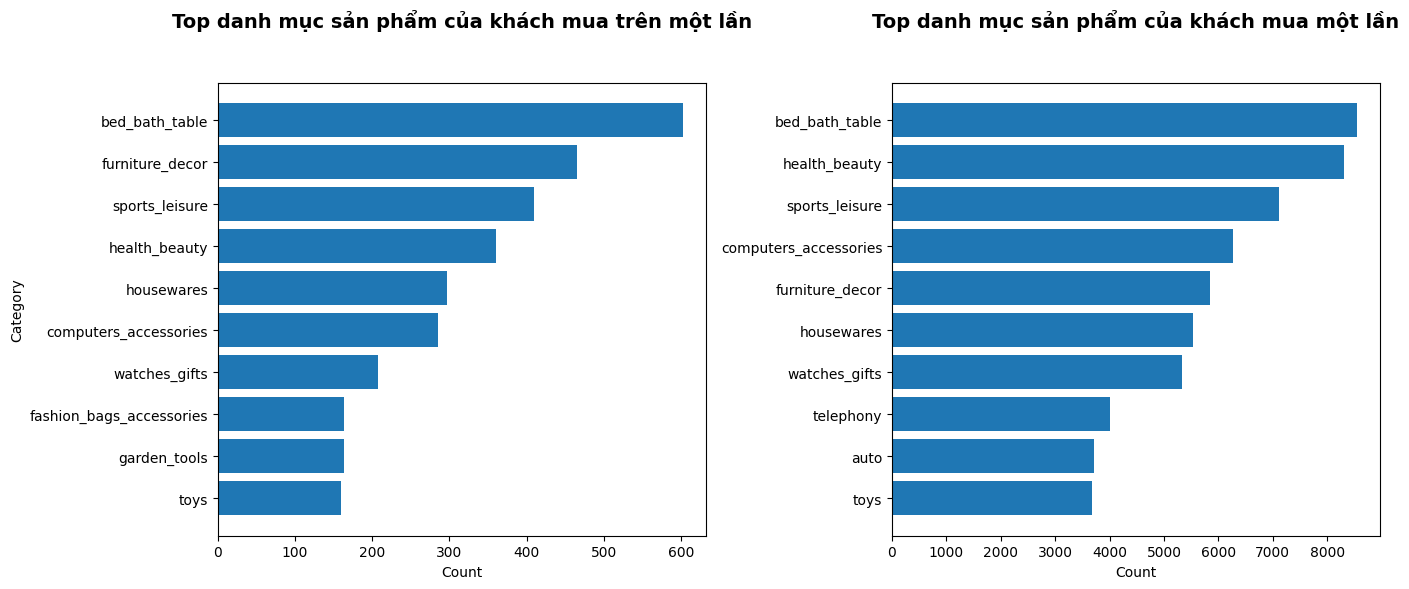

In [254]:
df1 = top_categories_more_than_1_time_df.sort_values("count")
df2 = top_categories_one_time_df.sort_values("count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Top categories nhóm mua >1 lần
axes[0].barh(df1["category"], df1["count"])
axes[0].set_title(
    "Top danh mục sản phẩm của khách mua trên một lần",
    fontsize=14,
    fontweight="bold",
    pad=40
)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

# Subplot 2: Top categories toàn bộ
axes[1].barh(df2["category"], df2["count"])
axes[1].set_title(
    "Top danh mục sản phẩm của khách mua một lần",
    fontsize=14,
    fontweight="bold",
    pad=40
)
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

**Nhận xét**

- Giả thuyết "khách quay lại chủ yếu mua hàng tiêu dùng nhanh" không đúng, cả khách quay lại và khách mua một lần đều tập trung vào nhóm "Nhà cửa & Đời sống".
- Danh mục `bed_bath_table` đứng Top 1 ở cả hai nhóm, cho thấy đây là nhu cầu cốt lõi, phổ quát của khách hàng.
- Danh mục `health_beauty` đứng Top 2 ở nhóm mua một lần nhưng chỉ đứng Top 4 ở nhóm khách quay lại, cho thấy tiêu dùng nhanh không phải yếu tố quyết định hành vi quay lại.

**Insight**

- Động lực mua sắm cốt lõi là giống nhau: Cả hai nhóm đều có nhu cầu cơ bản về các mặt hàng sinh hoạt và đời sống.
- Nhóm mua 1 lần có sự xuất hiện của auto (ô tô) và telephony(điện thoại), cho thấy đây có thể là những giao dịch lớn, không lặp lại thường xuyên.


#### Nhóm khách hàng quay lại có trải nghiệm lần mua đầu tiên tốt hơn nhóm bỏ đi không?

In [305]:
# Dataframe chứa các đơn hàng đầu tiên của từng khách
df_orders = orders.merge(reviews, on="order_id", how="left")
df = customers.merge(df_orders, on="customer_id", how="left")
df = df.sort_values(["customer_unique_id", "order_purchase_timestamp"])
df["row_number"] = df.groupby("customer_unique_id").cumcount() + 1
df = df[df["row_number"] == 1]
df = df[["customer_unique_id", "review_score"]]
df = df[df["review_score"].notnull()]

# Dataframe gồm cột khách và số đơn đã mua
df1 = pd.read_csv("../data/3_model/featured_data.csv")
df1 = df1[["customer_unique_id", "total_orders"]]

# Nhóm khách mua 1 đơn
df_1_orders = df1[df1["total_orders"] == 1]
df_1_orders = df_1_orders.merge(df, on="customer_unique_id", how="left")
df_1_orders = df_1_orders[df_1_orders["review_score"].notnull()]
df_1_orders = df_1_orders.drop(columns=["total_orders"])

# Nhóm khách mua > 1 đơn
df_more_than_1_orders = df1[df1["total_orders"] > 1]
df_more_than_1_orders = df_more_than_1_orders.merge(df, on="customer_unique_id", how="left")
df_more_than_1_orders = df_more_than_1_orders[df_more_than_1_orders["review_score"].notnull()]
df_more_than_1_orders = df_more_than_1_orders.drop(columns=["total_orders"])

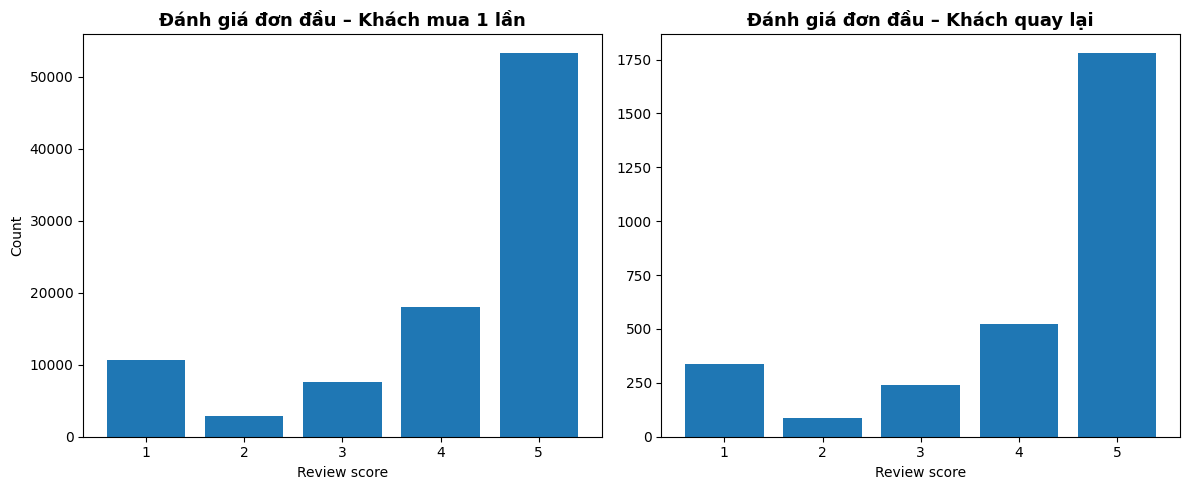

In [306]:
# Đếm số lượng review theo score
count_1 = df_1_orders["review_score"].value_counts().sort_index()
count_more = df_more_than_1_orders["review_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Nhóm mua 1 lần
axes[0].bar(count_1.index, count_1.values)
axes[0].set_title("Đánh giá đơn đầu – Khách mua 1 lần", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("Count")

# Nhóm mua >1 lần
axes[1].bar(count_more.index, count_more.values)
axes[1].set_title("Đánh giá đơn đầu – Khách quay lại", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Review score")

plt.tight_layout()
plt.show()

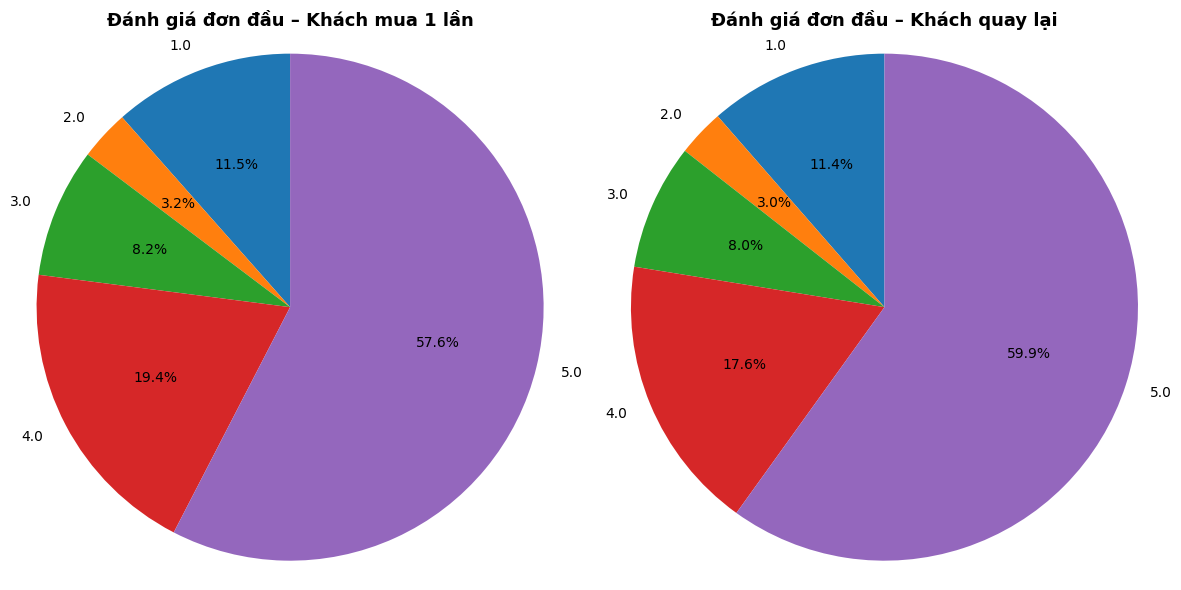

In [ ]:
# Đếm review_score
pie_1 = df_1_orders["review_score"].value_counts().sort_index()
pie_more = df_more_than_1_orders["review_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Nhóm mua 1 lần
axes[0].pie(
    pie_1.values,
    labels=pie_1.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title(
    "Đánh giá đơn đầu – Khách mua 1 lần",
    fontsize=13,
    fontweight="bold"
)
axes[0].axis("equal")

# Nhóm mua > 1 lần
axes[1].pie(
    pie_more.values,
    labels=pie_more.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title(
    "Đánh giá đơn đầu – Khách quay lại",
    fontsize=13,
    fontweight="bold"
)
axes[1].axis("equal")

plt.tight_layout()
plt.show()

**Nhận xét**
- Tỷ lệ đánh giá 5 sao ở nhóm Khách quay lại (59.9%) cao hơn một chút so với nhóm Khách mua 1 lần (57.6%).

**Insight**
- Mặc dù mức độ hài lòng ban đầu tương đương, phần lớn khách hàng vẫn chỉ mua 1 lần. Điều này cho thấy hành vi quay lại không được quyết định bởi trải nghiệm đơn đầu, mà bởi các yếu tố sau mua và nhu cầu dài hạn.